# Classification: K-Nearest Neighbors (scikit-learn)

This notebook builds a churn classifier using **K-Nearest Neighbors (KNN)** on the [IBM Telco Customer Churn dataset](https://github.com/IBM/telco-customer-churn-on-icp4d) — a real, publicly available dataset of 7,043 telecom customers with a mix of numeric and categorical features (contract type, services subscribed, monthly charges, tenure, etc.) and a binary label: did the customer churn?

End-to-end pipeline:
1. Get the data
2. Profile the data
3. Clean the data
4. Transform the data (encode + scale — scaling matters *a lot* for KNN)
5. Split into train / validation / test
6. Build the model: KNN (a distance-based, "lazy" learner — no real training happens)
7. Tune the key hyperparameter (`k`) using the validation set
8. Final evaluation on the held-out test set
9. Inference on a new, unseen customer
10. Save the model


## 0. Install & Import Libraries

In [1]:
# !pip install scikit-learn pandas numpy matplotlib seaborn joblib --quiet

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve,
)
import joblib

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Libraries loaded.")


Libraries loaded.


## 1. Get the Data

Loading the dataset from a local cache under `data/` if it exists; otherwise downloading it from the public source below and saving a local copy for next time:

`https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv`

Each row is one customer; the target column is `Churn` (`Yes`/`No`).


In [2]:
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
DATA_DIR = "data"
LOCAL_PATH = os.path.join(DATA_DIR, "Telco-Customer-Churn.csv")

os.makedirs(DATA_DIR, exist_ok=True)

if os.path.exists(LOCAL_PATH):
    print(f"Loading data from local cache: {LOCAL_PATH}")
    df_raw = pd.read_csv(LOCAL_PATH)
else:
    print(f"Local file not found. Downloading from {DATA_URL} ...")
    df_raw = pd.read_csv(DATA_URL)
    df_raw.to_csv(LOCAL_PATH, index=False)
    print(f"Saved local copy to: {LOCAL_PATH}")

print("Shape:", df_raw.shape)
df_raw.head()


Loading data from local cache: data\Telco-Customer-Churn.csv
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Profile the Data

Look at structure, types, missingness, and class balance before touching anything — this is where real-world messiness usually shows up.


In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
print("Churn distribution:")
print(df_raw["Churn"].value_counts(normalize=True).rename("proportion"))

print("\nNull count per column (as pandas sees it):")
print(df_raw.isna().sum())


Churn distribution:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Null count per column (as pandas sees it):
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
# TotalCharges is read in as an object (string) column, not numeric -- that's the first red flag.
print("TotalCharges dtype:", df_raw["TotalCharges"].dtype)

# Look for non-numeric entries hiding inside it
non_numeric_mask = pd.to_numeric(df_raw["TotalCharges"], errors="coerce").isna()
print("Rows where TotalCharges isn't a clean number:", non_numeric_mask.sum())
df_raw.loc[non_numeric_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]


TotalCharges dtype: object
Rows where TotalCharges isn't a clean number: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


Now checking the *rest* of the columns for the same kinds of hidden issues — a numeric-looking column stored as text (like `TotalCharges` above), blank/whitespace-only strings, and unexpected category values.

In [6]:
object_cols = df_raw.select_dtypes(include="object").columns.drop("customerID")

# 1) Any other "text" columns that are secretly mostly numeric?
print("Checking for hidden numeric columns...")
found_hidden_numeric = False
for col in object_cols:
    non_numeric = pd.to_numeric(df_raw[col], errors="coerce").isna()
    if 0 < non_numeric.sum() < len(df_raw):
        print(f"  {col}: {non_numeric.sum()} non-numeric rows out of {len(df_raw)}")
        found_hidden_numeric = True
if not found_hidden_numeric:
    print("  None found -- TotalCharges appears to be the only offender.")

# 2) Any blank / whitespace-only strings hiding in text columns?
print("\nChecking for blank/whitespace-only strings...")
found_blank = False
for col in object_cols:
    blank_count = (df_raw[col].astype(str).str.strip() == "").sum()
    if blank_count > 0:
        print(f"  {col}: {blank_count} blank/whitespace-only entries")
        found_blank = True
if not found_blank:
    print("  None found.")

# 3) Sanity-check categorical columns -- print unique values to catch typos/inconsistent labels
print("\nUnique values per categorical column:")
for col in object_cols:
    print(f"  {col}: {sorted(df_raw[col].unique())}")


Checking for hidden numeric columns...
  TotalCharges: 11 non-numeric rows out of 7043

Checking for blank/whitespace-only strings...
  TotalCharges: 11 blank/whitespace-only entries

Unique values per categorical column:
  gender: ['Female', 'Male']
  Partner: ['No', 'Yes']
  Dependents: ['No', 'Yes']
  PhoneService: ['No', 'Yes']
  MultipleLines: ['No', 'No phone service', 'Yes']
  InternetService: ['DSL', 'Fiber optic', 'No']
  OnlineSecurity: ['No', 'No internet service', 'Yes']
  OnlineBackup: ['No', 'No internet service', 'Yes']
  DeviceProtection: ['No', 'No internet service', 'Yes']
  TechSupport: ['No', 'No internet service', 'Yes']
  StreamingTV: ['No', 'No internet service', 'Yes']
  StreamingMovies: ['No', 'No internet service', 'Yes']
  Contract: ['Month-to-month', 'One year', 'Two year']
  PaperlessBilling: ['No', 'Yes']
  PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
  TotalCharges: [' ', '100.2', '100.25', '1

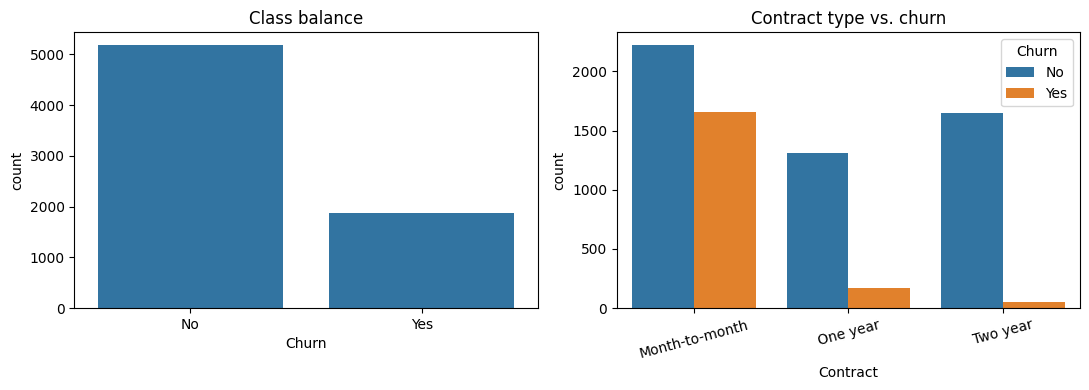

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=df_raw, x="Churn", ax=axes[0])
axes[0].set_title("Class balance")

sns.countplot(data=df_raw, x="Contract", hue="Churn", ax=axes[1])
axes[1].set_title("Contract type vs. churn")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


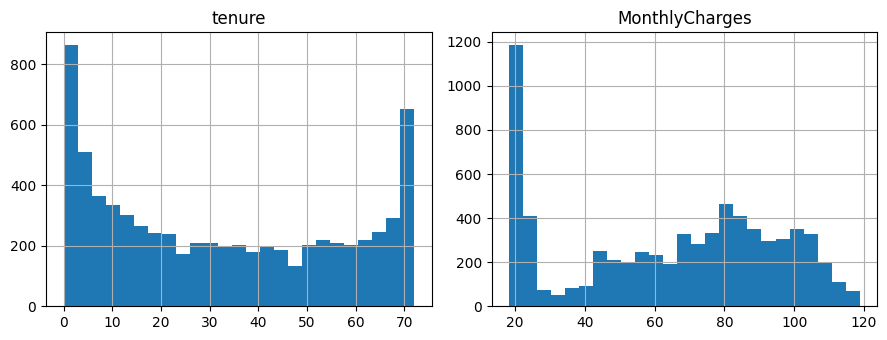

In [8]:
numeric_preview = ["tenure", "MonthlyCharges"]
df_raw[numeric_preview].hist(figsize=(9, 3.5), bins=25)
plt.tight_layout()
plt.show()


## 3. Clean the Data

Issues surfaced in profiling:
1. **`TotalCharges` is stored as text**, and 11 rows contain a blank string (`" "`) instead of a number — these turn out to all be brand-new customers with `tenure == 0` (no charges accumulated yet). Converting the column with `pd.to_numeric(..., errors="coerce")` turns those blanks into proper `NaN`s, which we then impute in the transform step (fit on train only, to avoid leakage).
2. **`customerID`** is a unique identifier with no predictive value — it gets dropped, otherwise a distance-based model would treat it as a meaningless extra dimension.
3. **`Churn`** (the target) is text (`Yes`/`No`) — encode it to `0`/`1` up front, since it's the label, not a feature (no leakage risk either way).
4. **Duplicate rows** — checked and dropped if any exist.


In [9]:
df = df_raw.copy()

# 1. Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# 2. Drop identifier column
df = df.drop(columns=["customerID"])

# 3. Encode target
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# 4. Drop exact duplicates
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows -> {len(df)} rows remaining")

print("\nRemaining missing values (to be imputed later, fit on train only):")
print(df.isna().sum()[df.isna().sum() > 0])


Dropped 22 duplicate rows -> 7021 rows remaining

Remaining missing values (to be imputed later, fit on train only):
TotalCharges    11
dtype: int64


## 4. Transform the Data: Encode + Scale

This is the step that matters most for KNN specifically.

- **Why scaling is critical here**: KNN classifies a point by *distance* (default: Euclidean) to its neighbors. `tenure` ranges roughly 0–72 and `MonthlyCharges` ranges roughly 18–120 — on raw scales, whichever feature happens to have bigger numbers dominates the distance calculation, regardless of which one is actually more predictive. `StandardScaler` (zero mean, unit variance) puts every numeric feature on equal footing before distance is computed. There's no learning step in KNN to compensate for this automatically, unlike models that *learn* per-feature weights — so scaling has to be done explicitly, up front.
- **Why one-hot encode the categorical columns** (`gender`, `Contract`, `InternetService`, `PaymentMethod`, etc.): KNN needs a numeric vector to compute distance on. One-hot encoding avoids implying a false ordinal relationship between categories (e.g. label-encoding `Contract` as `0/1/2` would wrongly imply `two-year` is "more" than `month-to-month` by a magnitude of 2).
- **Median imputation** for the missing `TotalCharges` values, fit on train only.

Everything is bundled into one scikit-learn `ColumnTransformer` + `Pipeline`, so the exact same fitted transformation (train-set statistics) is applied consistently to validation, test, and any new customer later.


In [10]:
target_col = "Churn"
feature_cols = [c for c in df.columns if c != target_col]
numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
categorical_features = [c for c in feature_cols if c not in numeric_features]

print("Numeric features    :", numeric_features)
print("Categorical features:", categorical_features)


Numeric features    : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [11]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

print("Preprocessor defined (not fit yet -- fitting happens on the train split only, in section 5).")


Preprocessor defined (not fit yet -- fitting happens on the train split only, in section 5).


## 5. Split into Train / Validation / Test (one-time random split)

Carve off the test set first (held out completely until the final evaluation), then split the remainder into train/validation. We stratify by `Churn` at every step since the classes are imbalanced (~73% / 27%) — stratification keeps that ratio consistent across all three splits.

**Avoiding leakage**: the `preprocessor` (imputer + scaler + encoder) is `fit` only on `X_train`. `X_val` and `X_test` are only ever `.transform()`-ed using those train-derived statistics — never re-fit.


In [12]:
X = df[numeric_features + categorical_features]
y = df[target_col]

TEST_SIZE = 0.2
VAL_SIZE = 0.1

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y,
)

val_fraction_of_temp = VAL_SIZE / (1 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_fraction_of_temp, random_state=SEED, stratify=y_temp,
)

print("Train size:", len(X_train))
print("Val size  :", len(X_val))
print("Test size :", len(X_test))

print("\nClass balance check (should all be close to the original ~73/27):")
for name, split_y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"  {name}: {split_y.value_counts(normalize=True).round(3).to_dict()}")


Train size: 4914
Val size  : 702
Test size : 1405

Class balance check (should all be close to the original ~73/27):
  train: {0: 0.736, 1: 0.264}
  val: {0: 0.735, 1: 0.265}
  test: {0: 0.735, 1: 0.265}


In [13]:
# Fit the preprocessor on TRAIN ONLY, then transform all three splits
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

feature_names_out = preprocessor.get_feature_names_out()
print("Processed feature count:", X_train_proc.shape[1])
print("\nTrain matrix shape:", X_train_proc.shape)


Processed feature count: 45

Train matrix shape: (4914, 45)


## 6. Build the Model: K-Nearest Neighbors

KNN's "training" step is really just storing `X_train_proc` and `y_train` — there's no gradient descent, no loss function, no iterative optimization. All the real work happens at **prediction time**:

1. Compute the distance from the new point to every stored training point (default: Euclidean / `minkowski` with `p=2`).
2. Take the `k` closest training points.
3. Predict the **majority class** among those `k` neighbors (or a distance-weighted vote if `weights="distance"`).

Key hyperparameters:
- **`n_neighbors` (k)**: too small (e.g. `k=1`) -> a very jagged decision boundary that's sensitive to noise/outliers (high variance, easy to overfit — at `k=1` a point's nearest neighbor is always itself, so training accuracy is trivially ~1.0). Too large -> the boundary gets oversmoothed and starts ignoring local structure (high bias, underfitting).
- **`weights`**: `"uniform"` (every neighbor gets an equal vote) vs. `"distance"` (closer neighbors get a bigger vote) — `"distance"` often helps with imbalanced classes like this one.
- **`metric`**: how "distance" is defined — `minkowski`/`euclidean` is standard once numeric + one-hot features are all scaled comparably.

We'll start with a baseline `k` and then tune it properly against the validation set in section 7.


In [24]:

# n_jobs:how many CPU cores to use
baseline_model = KNeighborsClassifier(n_neighbors=5, weights="uniform", metric="minkowski", p=2, n_jobs=-1)
baseline_model.fit(X_train_proc, y_train)

val_preds = baseline_model.predict(X_val_proc)
print("Baseline (k=5) validation accuracy:", round(accuracy_score(y_val, val_preds), 4))


Baseline (k=5) validation accuracy: 0.7521


## 7. Tune the Key Hyperparameter: Choosing `k`

Sweep `k` across a range and track train vs. validation accuracy to catch over/underfitting — the equivalent of tracking a learning curve, but here the x-axis is `k` rather than training iterations.

Also comparing `weights="uniform"` vs `weights="distance"` since it's cheap to check both.


In [26]:
k_values = list(range(1, 41, 2))  # odd values to avoid ties in binary classification
results = []

for k in k_values:
    for weight_mode in ["uniform", "distance"]:
        model = KNeighborsClassifier(n_neighbors=k, weights=weight_mode, metric="minkowski", p=2, n_jobs=-1)
        model.fit(X_train_proc, y_train)

        train_acc = accuracy_score(y_train, model.predict(X_train_proc))
        val_acc = accuracy_score(y_val, model.predict(X_val_proc))

        results.append({"k": k, "weights": weight_mode, "train_acc": train_acc, "val_acc": val_acc})

results_df = pd.DataFrame(results)
results_df.head(10)


,k,weights,train_acc,val_acc
0,1,uniform,0.997761,0.722222
1,1,distance,0.997761,0.722222
2,3,uniform,0.862230,0.752137
3,3,distance,0.997761,0.747863
4,5,uniform,0.836996,0.752137
5,5,distance,0.997761,0.750712
6,7,uniform,0.822751,0.772080
7,7,distance,0.997761,0.764957
8,9,uniform,0.819495,0.783476
9,9,distance,0.997761,0.776353


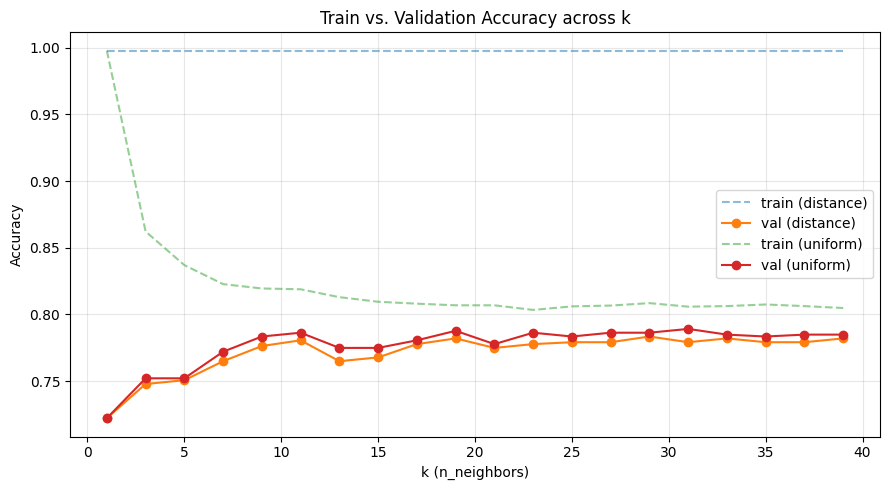

Best config on validation set:
k                  31
weights       uniform
train_acc    0.805861
val_acc      0.789174
Name: 30, dtype: object


In [27]:
fig, ax = plt.subplots(figsize=(9, 5))

for weight_mode, group in results_df.groupby("weights"):
    ax.plot(group["k"], group["train_acc"], "--", alpha=0.5, label=f"train ({weight_mode})")
    ax.plot(group["k"], group["val_acc"], "-o", label=f"val ({weight_mode})")

ax.set_xlabel("k (n_neighbors)")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs. Validation Accuracy across k")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_row = results_df.loc[results_df["val_acc"].idxmax()]
print("Best config on validation set:")
print(best_row)


In [18]:
BEST_K = int(best_row["k"])
BEST_WEIGHTS = best_row["weights"]

print(f"Selected hyperparameters -> k={BEST_K}, weights='{BEST_WEIGHTS}'")


Selected hyperparameters -> k=31, weights='uniform'


## 8. Final Evaluation on the Held-Out Test Set

The test set has not been touched until now. We refit on **train only** (not train+val, keeping val available as an honest checkpoint) using the selected hyperparameters, then evaluate once on test.


In [19]:
final_model = KNeighborsClassifier(n_neighbors=BEST_K, weights=BEST_WEIGHTS)
final_model.fit(X_train_proc, y_train)

test_preds = final_model.predict(X_test_proc)
test_probs = final_model.predict_proba(X_test_proc)[:, 1]

print("Test accuracy :", round(accuracy_score(y_test, test_preds), 4))
print("Test precision:", round(precision_score(y_test, test_preds), 4))
print("Test recall   :", round(recall_score(y_test, test_preds), 4))
print("Test F1       :", round(f1_score(y_test, test_preds), 4))
print("Test ROC-AUC  :", round(roc_auc_score(y_test, test_probs), 4))

print("\nFull classification report:")
print(classification_report(y_test, test_preds, target_names=["not churned", "churned"]))


Test accuracy : 0.7929
Test precision: 0.6224
Test recall   : 0.5538
Test F1       : 0.5861
Test ROC-AUC  : 0.83

Full classification report:
              precision    recall  f1-score   support

 not churned       0.85      0.88      0.86      1033
     churned       0.62      0.55      0.59       372

    accuracy                           0.79      1405
   macro avg       0.73      0.72      0.72      1405
weighted avg       0.79      0.79      0.79      1405



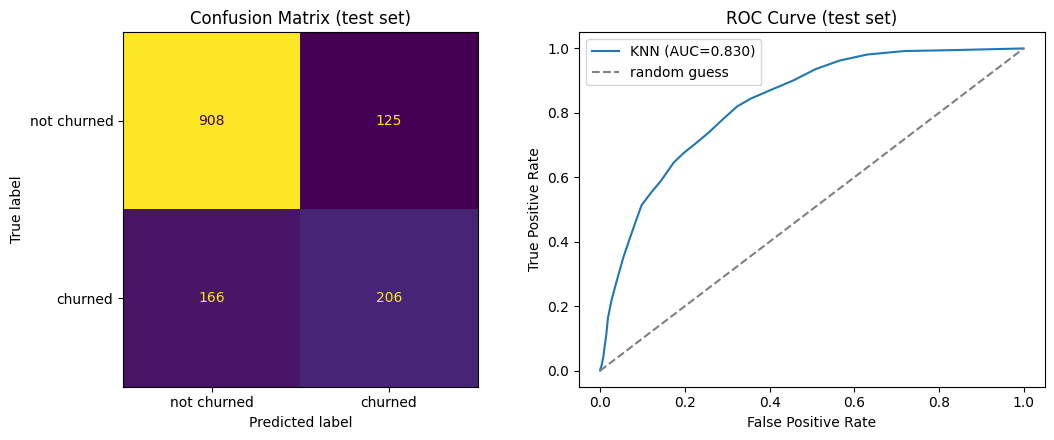

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(cm, display_labels=["not churned", "churned"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (test set)")

fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[1].plot(fpr, tpr, label=f"KNN (AUC={roc_auc_score(y_test, test_probs):.3f})")
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="random guess")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (test set)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Inference on a New, Unseen Customer

A new customer is just a raw dict of feature values -> it must go through the **exact same fitted `preprocessor`** (impute -> scale -> one-hot) before it can be fed to the model.


In [21]:
def predict_churn(raw_features: dict, model, preprocessor):
    # raw_features: dict with keys matching the original column names
    input_df = pd.DataFrame([raw_features])
    input_proc = preprocessor.transform(input_df)
    pred = model.predict(input_proc)[0]
    prob = model.predict_proba(input_proc)[0, 1]
    return ("churned" if pred == 1 else "not churned"), prob


new_customer = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 2,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 95.50,
    "TotalCharges": 191.0,
}

label, prob = predict_churn(new_customer, final_model, preprocessor)
print(f"Prediction: {label} (probability of churn: {prob:.3f})")


Prediction: churned (probability of churn: 0.839)


## 10. Save the Model (optional)

In [22]:
joblib.dump({"model": final_model, "preprocessor": preprocessor}, "knn_churn_classifier.joblib")
print("Model + preprocessor saved to knn_churn_classifier.joblib")

# To reload later:
# bundle = joblib.load("knn_churn_classifier.joblib")
# final_model, preprocessor = bundle["model"], bundle["preprocessor"]


Model + preprocessor saved to knn_churn_classifier.joblib
